# Baseline model selection for weekly business-window forecasts

This notebook selects baseline forecasting models for one-week operational forecasts. The model-selection target is one weekly aggregated demand value from `data/processed/transactions_dst_over_weeks/`, with `forecast_periods=1` and `step=1`.

Implemented sections: evaluation setup, evaluation sample with metric-sensitivity conclusion, main model ranking, per-series robustness, bias/volume calibration, and final baseline selection.

## 1. Evaluation setup

The report used here is `weekly_1_1`: a one-week forecast horizon with a one-week rolling step. The definition of a store week is handled upstream in the weekly aggregation. The baseline-selection code consumes one weekly demand value per product-store-week, so it can be used with Monday-Saturday weeks and with Sunday-open store weeks once those weeks are present in the aggregated weekly data.

Model families are compared by demand pattern:

- `smooth` and `erratic`: naive, mean, moving average, simple exponential smoothing, and damped-trend ETS. These are regular-demand candidates. In this weekly use case, smoothing and mean-type models are strong when the goal is stable weekly kilogram volume rather than reacting to single transaction spikes.
- `intermittent` and `lumpy`: naive, mean, moving average, Croston, SBA, and TSB. These are sparse-demand candidates. In this weekly use case, recent-window models can become competitive because weekly aggregation already reduces daily zero inflation.

In [37]:
from pathlib import Path
import sys

import duckdb
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve()
if not (ROOT / "src").is_dir():
    ROOT = next(parent for parent in ROOT.parents if (parent / "src").is_dir())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

REPORT_ID = "weekly_1_1"
FORECAST_PERIODS = 1
STEP = 1
MIN_TRAIN_SIZE = 26
RESULT_DIR = ROOT / "reports" / "baseline" / REPORT_ID
DATA_DIR = ROOT / "data" / "processed" / "transactions_dst_over_weeks"

DEMAND_ORDER = ["smooth", "erratic", "intermittent", "lumpy"]
METRIC_COLUMNS = [
    "wape_pooled",
    "wape_median",
    "mae_mean",
    "rmse_mean",
    "mase_mean",
    "mase_median",
    "bias_mean",
    "forecast_to_actual_ratio",
]

MODEL_LABELS = {
    "naive": "Naive",
    "mean": "Mean",
    "moving_average_4": "Moving average (4)",
    "simple_exponential_smoothing": "SES",
    "damped_trend_ets": "Damped-trend ETS",
    "croston": "Croston",
    "sba": "SBA",
    "tsb": "TSB",
}

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:.4f}".format)

print(f"Baseline report id: {REPORT_ID}")
print(f"Baseline report directory exists: {RESULT_DIR.exists()}")

Baseline report id: weekly_1_1
Baseline report directory exists: True


In [38]:
required_files = {
    "evaluation_keys": RESULT_DIR / "baseline_evaluation_keys.csv",
    "window_scores": RESULT_DIR / "baseline_window_scores.csv",
    "series_scores": RESULT_DIR / "baseline_series_scores.csv",
    "summary": RESULT_DIR / "baseline_model_summary.csv",
    "best_by_cluster": RESULT_DIR / "baseline_best_by_cluster.csv",
}
missing = [path for path in required_files.values() if not path.exists()]
if missing:
    command = ".venv/bin/python -m src.models.model_selection.best_baseline --horizon weekly --forecast-periods 1 --step 1 --min-train-size 26 --n-jobs 1"
    raise FileNotFoundError("Missing baseline report files. Run from the project root: " + command)

evaluation_keys = pd.read_csv(required_files["evaluation_keys"])
window_scores = pd.read_csv(required_files["window_scores"], parse_dates=["forecast_origin", "period_start"])
series_scores = pd.read_csv(required_files["series_scores"])
summary = pd.read_csv(required_files["summary"])
best_by_cluster = pd.read_csv(required_files["best_by_cluster"])

for frame in (evaluation_keys, window_scores, series_scores, summary, best_by_cluster):
    if "demand_class" in frame.columns:
        frame["demand_class"] = pd.Categorical(frame["demand_class"], categories=DEMAND_ORDER, ordered=True)

print(f"Evaluated series: {len(evaluation_keys):,}")
print(f"Forecast rows: {len(window_scores):,}")
print(f"Series/model score rows: {len(series_scores):,}")
print(f"Cluster/model score rows: {len(summary):,}")

Evaluated series: 131
Forecast rows: 17,114
Series/model score rows: 730
Cluster/model score rows: 22


In [39]:
parquet_glob = str(DATA_DIR / "*.parquet")
con = duckdb.connect()
week_summary = con.execute(
    """
    SELECT
        MIN(CAST(DATE AS DATE)) AS first_week_start,
        MAX(CAST(DATE AS DATE)) AS last_week_start,
        COUNT(*) AS weekly_rows,
        COUNT(DISTINCT MARKT_ID) AS stores,
        COUNT(DISTINCT ARTIKEL_ID) AS articles,
        SUM(CAST(ABVERKAUFTE_MENGE_KG AS DOUBLE)) AS demand_kg
    FROM read_parquet(?)
    """,
    [parquet_glob],
).fetchdf()

active_days_distribution = con.execute(
    """
    SELECT
        active_days_in_week,
        COUNT(*) AS weekly_rows
    FROM read_parquet(?)
    GROUP BY active_days_in_week
    ORDER BY active_days_in_week
    """,
    [parquet_glob],
).fetchdf()

display(week_summary)
display(active_days_distribution)
print(f"Configured target: {FORECAST_PERIODS} aggregated week ahead, rolling step {STEP} week.")
print(f"Training history used for this sample report: {MIN_TRAIN_SIZE} weeks before the first forecast origin.")

,first_week_start,last_week_start,weekly_rows,stores,articles,demand_kg
0,2025-04-14,2026-06-29,11254,21,43,8713.0260


,active_days_in_week,weekly_rows
0,1,73
1,2,351
2,3,49
3,4,253
4,5,2023
5,6,8505


Configured target: 1 aggregated week ahead, rolling step 1 week.
Training history used for this sample report: 26 weeks before the first forecast origin.


## 2. Evaluation sample

The evaluation sample summarizes which product-store demand patterns are represented in the rolling-origin benchmark and how many model windows contribute to each demand pattern.

In [40]:
sample_by_class = (
    evaluation_keys.groupby("demand_class", observed=True)
    .agg(
        n_series=("ARTIKEL_ID", "size"),
        total_demand_kg=("series_total_demand", "sum"),
        median_active_periods=("active_periods", "median"),
        median_demand_periods=("demand_periods", "median"),
        median_ADI=("ADI", "median"),
        median_CV2=("CV2", "median"),
    )
    .reset_index()
)

window_counts = (
    summary.groupby("demand_class", observed=True)
    .agg(n_windows=("n_windows", "max"), n_models=("model", "nunique"))
    .reset_index()
)

evaluation_sample = sample_by_class.merge(window_counts, on="demand_class", how="left")
display(evaluation_sample.style.format({
    "total_demand_kg": "{:,.2f}",
    "median_active_periods": "{:,.0f}",
    "median_demand_periods": "{:,.0f}",
    "median_ADI": "{:.2f}",
    "median_CV2": "{:.2f}",
    "n_windows": "{:,.0f}",
}))

,demand_class,n_series,total_demand_kg,median_active_periods,median_demand_periods,median_ADI,median_CV2,n_windows,n_models
0,smooth,48,"4,117.07",57,56,1.03,0.27,"1,424",5
1,erratic,8,466.10,59,48,1.21,0.67,242,5
2,intermittent,39,"1,596.97",41,16,2.42,0.30,692,6
3,lumpy,36,"1,324.57",48,25,1.90,0.72,772,6


## 3. Main model ranking

The ranking compares all candidate baselines within each demand pattern. Lower error metrics are better; `forecast_to_actual_ratio` is best near `1.0`.

In [42]:
ranking = summary.copy()
ranking["model_label"] = ranking["model"].map(MODEL_LABELS).fillna(ranking["model"])
ranking["rank_wape_pooled"] = ranking.groupby("demand_class", observed=True)["wape_pooled"].rank(method="dense")
ranking = ranking.sort_values(["demand_class", "rank_wape_pooled", "model"])

ranking_table = ranking[[
    "demand_class",
    "model_label",
    "wape_pooled",
    "wape_median",
    "rmse_mean",
    "mase_mean",
    "mase_median",
    "mae_mean",
    "bias_mean",
    "forecast_to_actual_ratio",
    "n_windows",
]]
display(ranking_table.style.format({
    "wape_pooled": "{:.3f}",
    "wape_median": "{:.3f}",
    "rmse_mean": "{:.3f}",
    "mase_mean": "{:.3f}",
    "mase_median": "{:.3f}",
    "mae_mean": "{:.3f}",
    "bias_mean": "{:.3f}",
    "forecast_to_actual_ratio": "{:.3f}",
    "n_windows": "{:,.0f}",
}).background_gradient(subset=["wape_pooled", "wape_median", "rmse_mean", "mase_mean", "mase_median"], cmap="YlOrRd"))

,demand_class,model_label,wape_pooled,wape_median,rmse_mean,mase_mean,mase_median,mae_mean,bias_mean,forecast_to_actual_ratio,n_windows
4,smooth,SES,0.399,0.423,0.785,0.746,0.745,0.620,0.055,1.032,"1,424"
1,smooth,Mean,0.408,0.431,0.802,0.756,0.770,0.632,-0.031,0.974,"1,424"
0,smooth,Damped-trend ETS,0.413,0.427,0.804,0.775,0.763,0.646,0.136,1.085,"1,424"
2,smooth,Moving average (4),0.425,0.449,0.835,0.795,0.765,0.666,0.064,1.036,"1,424"
3,smooth,Naive,0.511,0.562,1.016,0.944,0.939,0.794,0.049,1.027,"1,424"
6,erratic,Mean,0.727,0.689,0.981,0.838,0.839,0.775,-0.038,0.951,242
9,erratic,SES,0.783,0.730,1.030,0.878,0.901,0.832,0.096,1.072,242
7,erratic,Moving average (4),0.798,0.772,1.059,0.904,0.915,0.846,0.068,1.051,242
5,erratic,Damped-trend ETS,0.832,0.796,1.077,0.921,0.949,0.894,0.303,1.249,242
8,erratic,Naive,0.963,0.899,1.335,1.062,1.044,1.005,0.043,1.038,242


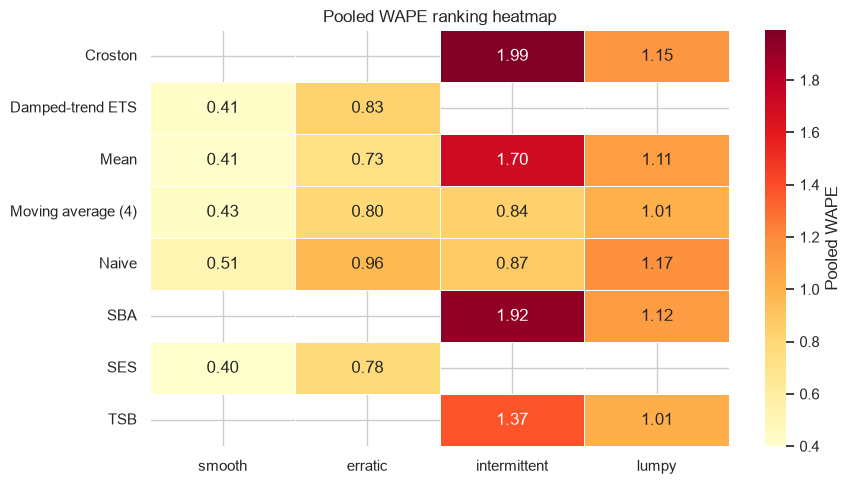

In [43]:
present_classes = [cls for cls in DEMAND_ORDER if cls in summary["demand_class"].astype(str).unique()]

heatmap_values = (
    ranking.pivot(index="model_label", columns="demand_class", values="wape_pooled")
    .reindex(columns=present_classes)
    .sort_index()
)

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(
    heatmap_values,
    annot=True,
    fmt=".2f",
    cmap="YlOrRd",
    linewidths=0.5,
    cbar_kws={"label": "Pooled WAPE"},
    ax=ax,
)
ax.set_title("Pooled WAPE ranking heatmap")
ax.set_xlabel("")
ax.set_ylabel("")

plt.tight_layout()

## 4. Per-series robustness

Cluster-level WAPE answers the total-volume question. Per-series diagnostics show whether the selected baseline is also competitive across individual product-store series.

The win-count table below answers: for how many product-store series did each model achieve the lowest per-series WAPE inside its demand class? This is a robustness diagnostic, not the final selection rule. The final selection still uses cluster-level pooled WAPE.

In [44]:
finite_series_scores = (
    series_scores.replace([np.inf, -np.inf], np.nan)
    .dropna(subset=["wape", "rmse", "mase"])
    .copy()
)
finite_series_scores = finite_series_scores.rename(columns={"wape": "per_series_wape"})
finite_series_scores["model_label"] = finite_series_scores["model"].map(MODEL_LABELS).fillna(finite_series_scores["model"])

series_id_cols = ["ARTIKEL_ID", "MARKT_ID", "demand_class"]
best_series_idx = finite_series_scores.groupby(series_id_cols, observed=True)["per_series_wape"].idxmin()
series_winners = finite_series_scores.loc[best_series_idx].copy()

series_totals = (
    finite_series_scores[series_id_cols]
    .drop_duplicates()
    .groupby("demand_class", observed=True)
    .size()
    .rename("n_series")
)

win_counts = (
    series_winners.groupby(["demand_class", "model_label"], observed=True)
    .size()
    .rename("series_win_count")
    .reset_index()
)
win_count_table = win_counts.merge(series_totals.reset_index(), on="demand_class", how="left")
win_count_table["series_win_share"] = win_count_table["series_win_count"] / win_count_table["n_series"]
win_count_table = (
    win_count_table.sort_values(["demand_class", "series_win_count", "model_label"], ascending=[True, False, True])
    .reset_index(drop=True)
)

display(win_count_table.style.format({
    "series_win_count": "{:,.0f}",
    "n_series": "{:,.0f}",
    "series_win_share": "{:.1%}",
}))

,demand_class,model_label,series_win_count,n_series,series_win_share
0,smooth,Mean,23,48,47.9%
1,smooth,SES,12,48,25.0%
2,smooth,Damped-trend ETS,6,48,12.5%
3,smooth,Moving average (4),5,48,10.4%
4,smooth,Naive,2,48,4.2%
5,erratic,Mean,5,8,62.5%
6,erratic,Damped-trend ETS,1,8,12.5%
7,erratic,Moving average (4),1,8,12.5%
8,erratic,Naive,1,8,12.5%
9,intermittent,Naive,16,32,50.0%


In [ ]:
def model_order_for_class(demand_class: str) -> list[str]:
    class_models = summary.loc[summary["demand_class"].astype(str) == demand_class].sort_values("wape_pooled")
    return class_models["model"].map(MODEL_LABELS).fillna(class_models["model"]).tolist()


def plot_series_metric_by_class(metric: str, ylabel: str) -> None:
    for demand_class in present_classes:
        class_scores = finite_series_scores[finite_series_scores["demand_class"].astype(str) == demand_class].copy()
        if class_scores.empty:
            continue

        model_order = model_order_for_class(demand_class)
        fig_width = max(7, 1.2 * len(model_order))
        fig, ax = plt.subplots(figsize=(fig_width, 4))
        sns.boxplot(
            data=class_scores,
            x="model_label",
            y=metric,
            order=model_order,
            showfliers=False,
            ax=ax,
        )
        ax.set_title(f"{demand_class}: {ylabel}")
        ax.set_xlabel("")
        ax.set_ylabel(ylabel)
        ax.tick_params(axis="x", rotation=30)
        plt.tight_layout()
        plt.show()


plot_series_metric_by_class("per_series_wape", "Per-series WAPE")
plot_series_metric_by_class("rmse", "Per-series RMSE")
plot_series_metric_by_class("mase", "Per-series MASE")

## 6. Bias and volume calibration

The best baseline should not only minimize absolute error; it should also avoid systematic over- or under-forecasting. `forecast_to_actual_ratio` near `1.0` means forecasted kilograms match actual kilograms at cluster level.

In [10]:
calibration = summary.copy()
calibration["model_label"] = calibration["model"].map(MODEL_LABELS).fillna(calibration["model"])
calibration["volume_error_pct"] = (calibration["forecast_to_actual_ratio"] - 1.0) * 100
calibration = calibration.sort_values(["demand_class", "forecast_to_actual_ratio", "model"])

display(calibration[[
    "demand_class",
    "model_label",
    "bias_mean",
    "forecast_to_actual_ratio",
    "volume_error_pct",
    "forecast_sum",
    "actual_sum",
]].style.format({
    "bias_mean": "{:.4f}",
    "forecast_to_actual_ratio": "{:.3f}",
    "volume_error_pct": "{:+.1f}%",
    "forecast_sum": "{:,.1f}",
    "actual_sum": "{:,.1f}",
}).background_gradient(subset=["forecast_to_actual_ratio"], cmap="RdYlGn_r"))

,demand_class,model_label,bias_mean,forecast_to_actual_ratio,volume_error_pct,forecast_sum,actual_sum
1,smooth,Mean,-0.0309,0.974,-2.6%,"2,231.6","2,290.2"
3,smooth,Naive,0.0491,1.027,+2.7%,"2,353.2","2,290.2"
4,smooth,SES,0.0553,1.032,+3.2%,"2,364.3","2,290.2"
2,smooth,Moving average (4),0.0639,1.036,+3.6%,"2,372.4","2,290.2"
0,smooth,Damped-trend ETS,0.1357,1.085,+8.5%,"2,484.5","2,290.2"
6,erratic,Mean,-0.0385,0.951,-4.9%,253.3,266.5
8,erratic,Naive,0.0426,1.038,+3.8%,276.7,266.5
7,erratic,Moving average (4),0.0676,1.051,+5.1%,280.1,266.5
9,erratic,SES,0.0960,1.072,+7.2%,285.6,266.5
5,erratic,Damped-trend ETS,0.3034,1.249,+24.9%,332.8,266.5


## 7. Large-error weeks joined to weekly context

This diagnostic inspects the largest absolute forecast errors for the selected baseline models. It joins those forecast rows back to the weekly aggregated data so action, discount, and week-composition columns are visible. The rows are selected by absolute error instead of percentage error because absolute error contributes directly to pooled WAPE.

In [11]:
selected_models = best_by_cluster[["demand_class", "model"]].rename(columns={"model": "selected_model"})
selected_error_weeks = window_scores.merge(selected_models, on="demand_class", how="inner")
selected_error_weeks = selected_error_weeks[
    selected_error_weeks["model"] == selected_error_weeks["selected_model"]
].copy()

selected_error_weeks["signed_error"] = selected_error_weeks["forecast"] - selected_error_weeks["actual"]
selected_error_weeks["abs_error"] = selected_error_weeks["signed_error"].abs()
selected_error_weeks["model_label"] = selected_error_weeks["model"].map(MODEL_LABELS).fillna(selected_error_weeks["model"])

cluster_abs_error = (
    selected_error_weeks.groupby("demand_class", observed=True)["abs_error"]
    .sum()
    .rename("cluster_abs_error")
    .reset_index()
)

top_error_weeks = (
    selected_error_weeks.sort_values("abs_error", ascending=False)
    .head(25)
    .merge(cluster_abs_error, on="demand_class", how="left")
)
top_error_weeks["period_start"] = pd.to_datetime(top_error_weeks["period_start"])
top_error_weeks["abs_error_share_of_cluster"] = top_error_weeks["abs_error"] / top_error_weeks["cluster_abs_error"]

join_keys = top_error_weeks[["ARTIKEL_ID", "MARKT_ID", "period_start"]].drop_duplicates().copy()
join_keys["period_start"] = join_keys["period_start"].dt.date
con.register("top_error_week_keys", join_keys)

weekly_context = con.execute(
    """
    SELECT
        CAST(w."DATE" AS DATE) AS period_start,
        w.ARTIKEL_ID,
        w.MARKT_ID,
        w.ARTIKEL_BEZ,
        w.N_WARENKLASSE_KBEZ,
        CAST(w.ABVERKAUFTE_MENGE_KG AS DOUBLE) AS weekly_actual_kg,
        CAST(w.UMS_VK_WERT AS DOUBLE) AS weekly_sales_value,
        w.AKTION_KENNZEICHEN,
        w.RABATT,
        w.ARTIKELRABATT,
        w.active_days_in_week,
        w.demand_days_in_week,
        w.zero_days_in_week
    FROM read_parquet(?) AS w
    INNER JOIN top_error_week_keys AS k
        ON w.ARTIKEL_ID = k.ARTIKEL_ID
        AND w.MARKT_ID = k.MARKT_ID
        AND CAST(w."DATE" AS DATE) = k.period_start
    """,
    [parquet_glob],
).fetchdf()
weekly_context["period_start"] = pd.to_datetime(weekly_context["period_start"])

error_context = top_error_weeks.merge(
    weekly_context,
    on=["ARTIKEL_ID", "MARKT_ID", "period_start"],
    how="left",
)
error_context["has_action_or_discount"] = (
    error_context[["AKTION_KENNZEICHEN", "RABATT", "ARTIKELRABATT"]]
    .fillna(0)
    .gt(0)
    .any(axis=1)
)

display_columns = [
    "demand_class",
    "model_label",
    "period_start",
    "ARTIKEL_ID",
    "MARKT_ID",
    "ARTIKEL_BEZ",
    "actual",
    "forecast",
    "signed_error",
    "abs_error",
    "abs_error_share_of_cluster",
    "AKTION_KENNZEICHEN",
    "RABATT",
    "ARTIKELRABATT",
    "has_action_or_discount",
    "active_days_in_week",
    "demand_days_in_week",
    "zero_days_in_week",
    "weekly_sales_value",
]

display(
    error_context[display_columns]
    .sort_values("abs_error", ascending=False)
    .style.format({
        "period_start": lambda value: value.strftime("%Y-%m-%d") if pd.notna(value) else "",
        "actual": "{:,.3f}",
        "forecast": "{:,.3f}",
        "signed_error": "{:+,.3f}",
        "abs_error": "{:,.3f}",
        "abs_error_share_of_cluster": "{:.1%}",
        "weekly_sales_value": "{:,.2f}",
    })
)

,demand_class,model_label,period_start,ARTIKEL_ID,MARKT_ID,ARTIKEL_BEZ,actual,forecast,signed_error,abs_error,abs_error_share_of_cluster,AKTION_KENNZEICHEN,RABATT,ARTIKELRABATT,has_action_or_discount,active_days_in_week,demand_days_in_week,zero_days_in_week,weekly_sales_value
0,lumpy,Moving average (4),2026-04-20,1382768,1100045,Fleischkäse ofengebacken,13.443,0.583,-12.860,12.860,2.3%,1,0,1,True,6,6,0,133.09
1,lumpy,Moving average (4),2026-03-09,1382768,1100045,Fleischkäse ofengebacken,12.426,0.725,-11.701,11.701,2.1%,1,0,1,True,6,6,0,123.00
2,lumpy,Moving average (4),2026-05-04,1382788,1300023,"Goldmarie Friesen Bratwurst, gebrüht",11.448,1.077,-10.371,10.371,1.8%,1,0,1,True,6,6,0,146.06
3,lumpy,Moving average (4),2026-04-27,1406063,1100043,SB Fleischkäse roh in Schale,10.395,2.313,-8.082,8.082,1.4%,0,1,1,True,5,5,0,43.02
4,lumpy,Moving average (4),2025-12-29,1382788,1300023,"Goldmarie Friesen Bratwurst, gebrüht",7.897,0.000,-7.897,7.897,1.4%,1,0,1,True,5,5,0,101.88
5,lumpy,Moving average (4),2026-05-25,1382768,1100045,Fleischkäse ofengebacken,7.978,0.246,-7.732,7.732,1.4%,1,0,1,True,5,4,1,63.01
6,erratic,Mean,2025-11-03,1382768,1300004,Fleischkäse ofengebacken,9.748,2.105,-7.643,7.643,3.9%,0,1,1,True,6,6,0,84.01
7,smooth,SES,2026-01-12,1382767,1350061,Fleischwurst ohne Knoblauch,11.629,4.708,-6.921,6.921,0.8%,1,0,1,True,6,6,0,135.62
8,lumpy,Moving average (4),2026-06-08,1382788,1300023,"Goldmarie Friesen Bratwurst, gebrüht",0.000,6.753,+6.753,6.753,1.2%,0,0,0,False,6,0,6,0.00
9,intermittent,Moving average (4),2026-04-06,1382788,1100045,"Goldmarie Friesen Bratwurst, gebrüht",6.786,0.112,-6.674,6.674,1.8%,1,1,1,True,5,5,0,66.01


In [12]:
top_error_context_summary = (
    error_context.groupby("demand_class", observed=True)
    .agg(
        top_error_weeks=("abs_error", "size"),
        total_abs_error=("abs_error", "sum"),
        weeks_with_action_or_discount=("has_action_or_discount", "sum"),
        share_with_action_or_discount=("has_action_or_discount", "mean"),
        mean_actual=("actual", "mean"),
        mean_forecast=("forecast", "mean"),
        mean_abs_error=("abs_error", "mean"),
    )
    .reset_index()
)

display(top_error_context_summary.style.format({
    "top_error_weeks": "{:,.0f}",
    "total_abs_error": "{:,.3f}",
    "weeks_with_action_or_discount": "{:,.0f}",
    "share_with_action_or_discount": "{:.1%}",
    "mean_actual": "{:,.3f}",
    "mean_forecast": "{:,.3f}",
    "mean_abs_error": "{:,.3f}",
}))

,demand_class,top_error_weeks,total_abs_error,weeks_with_action_or_discount,share_with_action_or_discount,mean_actual,mean_forecast,mean_abs_error
0,smooth,5,26.666,4,80.0%,8.958,5.523,5.333
1,erratic,1,7.643,1,100.0%,9.748,2.105,7.643
2,intermittent,5,30.744,4,80.0%,6.101,2.407,6.149
3,lumpy,14,101.919,12,85.7%,7.627,2.021,7.280


## 10. Final baseline selection

Use the selected model below as the benchmark for weekly aggregated one-week-ahead forecasts. The selected baseline can differ from the daily-window setup because the target is now one aggregated weekly quantity.

In [13]:
final_selection = best_by_cluster.copy()
final_selection["model_label"] = final_selection["model"].map(MODEL_LABELS).fillna(final_selection["model"])
final_selection["volume_error_pct"] = (final_selection["forecast_to_actual_ratio"] - 1.0) * 100
final_selection = final_selection.sort_values("demand_class")

display(final_selection[[
    "demand_class",
    "model_label",
    "selection_metric",
    "wape_pooled",
    "wape_median",
    "rmse_mean",
    "mase_mean",
    "mase_median",
    "bias_mean",
    "forecast_to_actual_ratio",
    "volume_error_pct",
    "n_series",
    "n_windows",
]].style.format({
    "wape_pooled": "{:.3f}",
    "wape_median": "{:.3f}",
    "rmse_mean": "{:.3f}",
    "mase_mean": "{:.3f}",
    "mase_median": "{:.3f}",
    "bias_mean": "{:.4f}",
    "forecast_to_actual_ratio": "{:.3f}",
    "volume_error_pct": "{:+.1f}%",
    "n_series": "{:,.0f}",
    "n_windows": "{:,.0f}",
}))

,demand_class,model_label,selection_metric,wape_pooled,wape_median,rmse_mean,mase_mean,mase_median,bias_mean,forecast_to_actual_ratio,volume_error_pct,n_series,n_windows
0,smooth,SES,wape_pooled,0.399,0.423,0.785,0.746,0.745,0.0553,1.032,+3.2%,48,"1,424"
1,erratic,Mean,wape_pooled,0.727,0.689,0.981,0.838,0.839,-0.0385,0.951,-4.9%,8,242
2,intermittent,Moving average (4),wape_pooled,0.839,1.772,0.720,0.463,0.329,0.1689,1.206,+20.6%,39,692
3,lumpy,Moving average (4),wape_pooled,1.007,1.111,0.954,0.669,0.687,0.0455,1.042,+4.2%,36,772
